# Challenge

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


## EDA

In [84]:
initial_x = pd.read_csv('data/challenge_train_features.csv')
y = pd.read_csv('data/challenge_train_revenue.csv')  



initial_data = pd.merge(initial_x, y, on='Unnamed: 0')

print(initial_data.iloc[25])
initial_data = initial_data.drop(columns=["title","webpage","poster_file","cast","keywords","crew","summary","company","collection"])

Unnamed: 0                                                         25
title                                                    I'm No Angel
language                                                           en
country                                                            US
length                                                           87.0
date                                                          10/6/33
genre                                                  Comedy,Romance
summary             The bold Tira works as dancing beauty and lion...
collection                                                        NaN
company                                            Paramount Pictures
webpage                                                           NaN
poster_file                           ZbD8UWL8zPKqOlGFQBZyqg7kjqs.jpg
cast                Mae West,Cary Grant,Gregory Ratoff,Edward Arno...
keywords                                              romantic comedy
crew                

(array([ 10.,  13.,   4.,   9.,  79., 139., 294., 607., 671., 174.]),
 array([ 0.69314718,  2.73800099,  4.7828548 ,  6.82770861,  8.87256242,
        10.91741623, 12.96227004, 15.00712385, 17.05197766, 19.09683147,
        21.14168528]),
 <BarContainer object of 10 artists>)

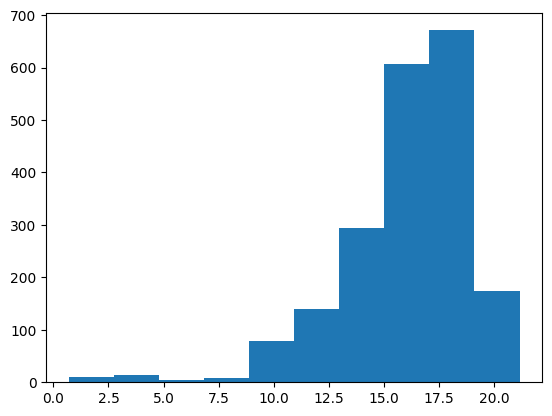

In [85]:
initial_data["log_revenue"] = np.log(initial_data["revenue"]+1)
plt.hist(initial_data['log_revenue'])

In [86]:
initial_data.info()
initial_data.dropna(inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        2000 non-null   int64  
 1   language          2000 non-null   object 
 2   country           1964 non-null   object 
 3   length            1999 non-null   float64
 4   date              2000 non-null   object 
 5   genre             1995 non-null   object 
 6   popularity_score  2000 non-null   float64
 7   budget            2000 non-null   int64  
 8   revenue           2000 non-null   int64  
 9   log_revenue       2000 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 156.4+ KB


In [87]:
initial_data["budget"].value_counts()
initial_data["budget"] = initial_data["budget"].replace(0, initial_data["budget"].median())
initial_data["budget"].value_counts()

budget
8500000     525
40000000     51
20000000     47
15000000     47
25000000     46
           ... 
19800000      1
39200000      1
4317946       1
360000        1
3062000       1
Name: count, Length: 318, dtype: int64

(array([   8.,    0.,    3.,    0.,    9.,   18.,   90.,  334., 1251.,
         248.]),
 array([ 0.69314718,  2.59940064,  4.50565411,  6.41190757,  8.31816103,
        10.2244145 , 12.13066796, 14.03692142, 15.94317489, 17.84942835,
        19.75568181]),
 <BarContainer object of 10 artists>)

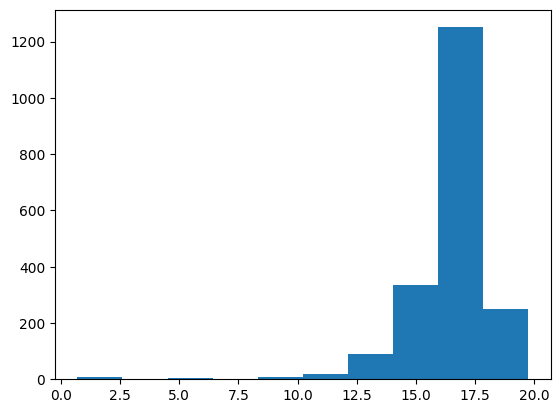

In [88]:
initial_data["log_budget"] = np.log(initial_data["budget"]+1)
plt.hist(initial_data['log_budget'])

In [89]:
initial_data.head(30)

,Unnamed: 0,language,country,length,date,genre,popularity_score,budget,revenue,log_revenue,log_budget
0,0,en,US,104.0,10/18/90,Drama,14.007329,42000000,119946358,18.602555,17.553180
1,1,en,US,104.0,9/8/13,Horror,8.698043,5000000,44030246,17.600387,15.424949
2,2,en,US,130.0,5/19/15,"Adventure,Family,Mystery,Science Fiction",22.296076,190000000,209154322,19.158583,19.062535
3,3,en,US,90.0,8/4/82,"Action,Comedy",9.442756,8500000,21134374,16.866411,15.955577
4,4,en,US,110.0,1/21/16,"Comedy,Romance",8.898988,38000000,112343513,18.537072,17.453097
5,5,en,US,89.0,11/15/96,"Family,Comedy",7.898202,60000000,129832389,18.681755,17.909855
6,6,en,US,84.0,8/8/86,Animation,6.759181,6000000,5849647,15.581892,15.607270
7,7,en,US,120.0,4/15/88,"Action,Crime,Drama",5.529808,6000000,46616067,17.657456,15.607270
8,8,en,"GB,US",120.0,12/13/71,"Adventure,Action,Thriller",12.004910,7200000,116019547,18.569269,15.789592
9,9,en,US,101.0,9/28/07,"Comedy,Drama,Romance",5.993691,8500000,5741608,15.563250,15.955577


In [90]:
initial_data["date_format"] = pd.to_datetime(initial_data["date"], format="%m/%d/%y")

initial_data.loc[initial_data["date_format"].dt.year > 2025, "date_format"] -= pd.offsets.DateOffset(years=100)
initial_data["year"] = initial_data["date_format"].dt.year
initial_data["month"] = initial_data["date_format"].dt.month

initial_data.head(30)

,Unnamed: 0,language,country,length,date,genre,popularity_score,budget,revenue,log_revenue,log_budget,date_format,year,month
0,0,en,US,104.0,10/18/90,Drama,14.007329,42000000,119946358,18.602555,17.553180,1990-10-18,1990,10
1,1,en,US,104.0,9/8/13,Horror,8.698043,5000000,44030246,17.600387,15.424949,2013-09-08,2013,9
2,2,en,US,130.0,5/19/15,"Adventure,Family,Mystery,Science Fiction",22.296076,190000000,209154322,19.158583,19.062535,2015-05-19,2015,5
3,3,en,US,90.0,8/4/82,"Action,Comedy",9.442756,8500000,21134374,16.866411,15.955577,1982-08-04,1982,8
4,4,en,US,110.0,1/21/16,"Comedy,Romance",8.898988,38000000,112343513,18.537072,17.453097,2016-01-21,2016,1
5,5,en,US,89.0,11/15/96,"Family,Comedy",7.898202,60000000,129832389,18.681755,17.909855,1996-11-15,1996,11
6,6,en,US,84.0,8/8/86,Animation,6.759181,6000000,5849647,15.581892,15.607270,1986-08-08,1986,8
7,7,en,US,120.0,4/15/88,"Action,Crime,Drama",5.529808,6000000,46616067,17.657456,15.607270,1988-04-15,1988,4
8,8,en,"GB,US",120.0,12/13/71,"Adventure,Action,Thriller",12.004910,7200000,116019547,18.569269,15.789592,1971-12-13,1971,12
9,9,en,US,101.0,9/28/07,"Comedy,Drama,Romance",5.993691,8500000,5741608,15.563250,15.955577,2007-09-28,2007,9


In [105]:
initial_data_copy=initial_data.copy()
initial_data_copy["genre"] = initial_data_copy["genre"].str.split(",")
df_exploded = initial_data_copy.explode("genre")
df_exploded["genre"] = df_exploded["genre"].str.strip()
genre_dummies = pd.get_dummies(df_exploded["genre"], prefix="genre")
print(genre_dummies.shape)
df_final = (
    df_exploded[["Unnamed: 0"]].join(genre_dummies)
    .groupby("Unnamed: 0").sum()
    .reset_index()
)
df_final.shape

(4855, 19)


(1961, 20)

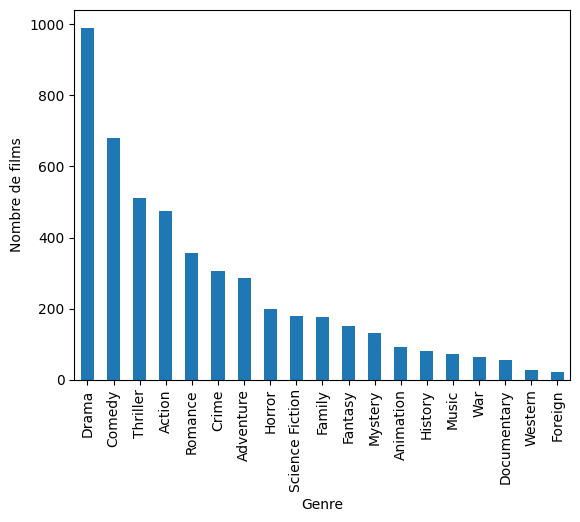

In [100]:
all_genres = initial_data["genre"].str.split(",")  # sépare par virgule
all_genres = all_genres.explode().str.strip()     # explode + supprime espaces
genre_counts = all_genres.value_counts()

genre_counts.head(30).plot(kind="bar")
plt.ylabel("Nombre de films")
plt.xlabel("Genre")
plt.show()



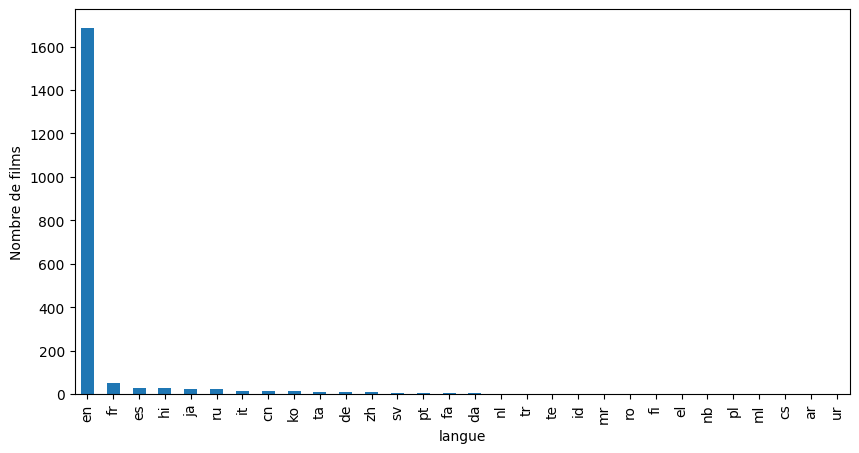

In [93]:
all_genres = initial_data["language"].str.split(",")  # sépare par virgule
all_genres = all_genres.explode().str.strip()     # explode + supprime espaces
genre_counts = all_genres.value_counts()


genre_counts.head(30).plot(kind="bar", figsize=(10,5))
plt.ylabel("Nombre de films")
plt.xlabel("langue")
plt.show()

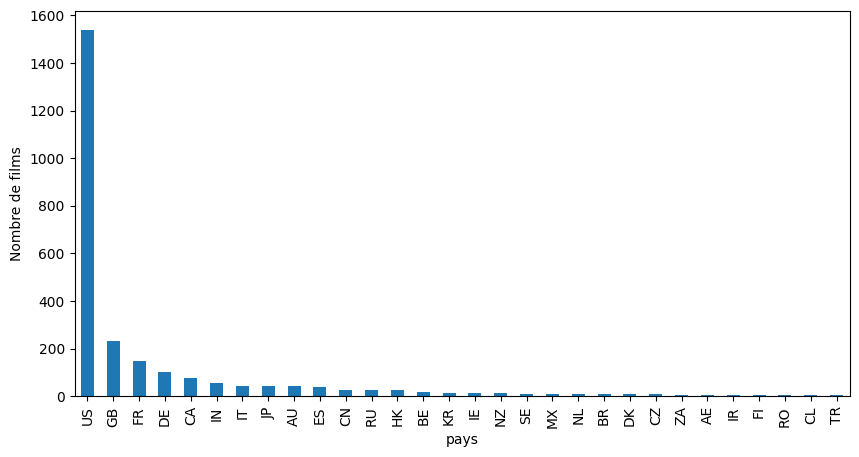

In [94]:
all_genres = initial_data["country"].str.split(",")  # sépare par virgule
all_genres = all_genres.explode().str.strip()     # explode + supprime espaces
genre_counts = all_genres.value_counts()


genre_counts.head(30).plot(kind="bar", figsize=(10,5))
plt.ylabel("Nombre de films")
plt.xlabel("pays")
plt.show()

Plus il y a de pays d ediffusion plus il ad echance d'avorid e revenue

Correlation: 0.23209785241837116


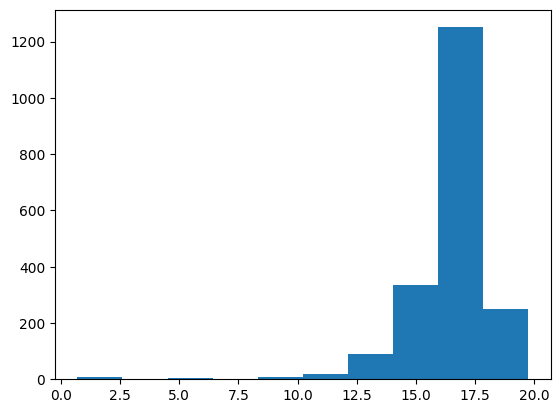

In [95]:
initial_data["log_budget"] = np.log(initial_data["budget"]+1)
plt.hist(initial_data['log_budget'])

corr = initial_data["log_budget"].corr(initial_data["popularity_score"])
print("Correlation:", corr)

In [96]:
initial_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1961 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Unnamed: 0        1961 non-null   int64         
 1   language          1961 non-null   object        
 2   country           1961 non-null   object        
 3   length            1961 non-null   float64       
 4   date              1961 non-null   object        
 5   genre             1961 non-null   object        
 6   popularity_score  1961 non-null   float64       
 7   budget            1961 non-null   int64         
 8   revenue           1961 non-null   int64         
 9   log_revenue       1961 non-null   float64       
 10  log_budget        1961 non-null   float64       
 11  date_format       1961 non-null   datetime64[ns]
 12  year              1961 non-null   int32         
 13  month             1961 non-null   int32         
dtypes: datetime64[ns](1), float64

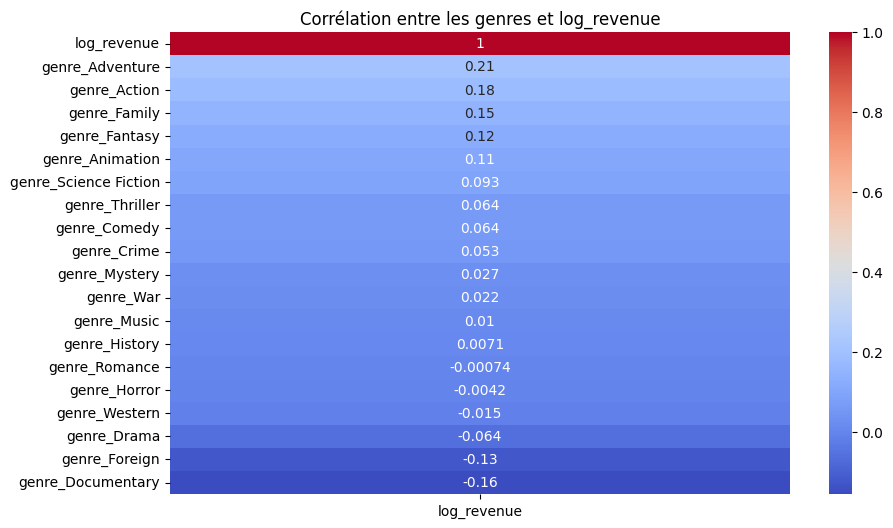

In [107]:
import seaborn as sns

corr_matrix = df_with_genres[[c for c in df_final.columns if c.startswith("genre_")] + ["log_revenue"]].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix[["log_revenue"]].sort_values(by="log_revenue", ascending=False), annot=True, cmap="coolwarm")
plt.title("Corrélation entre les genres et log_revenue")
plt.show()


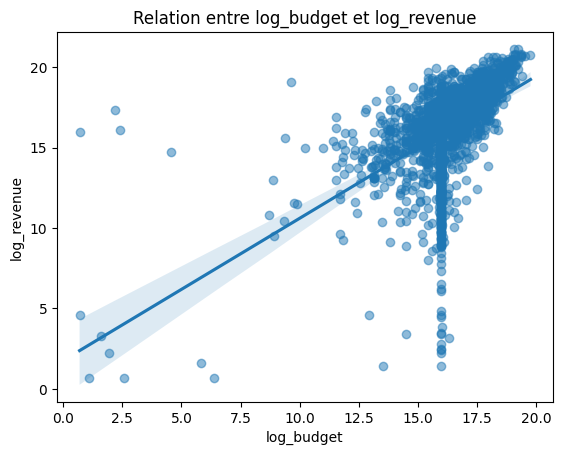

Corrélation : 0.5294120207944479


In [108]:
sns.regplot(x="log_budget", y="log_revenue", data=initial_data, scatter_kws={"alpha":0.5})
plt.title("Relation entre log_budget et log_revenue")
plt.show()

print("Corrélation :", initial_data["log_budget"].corr(initial_data["log_revenue"]))


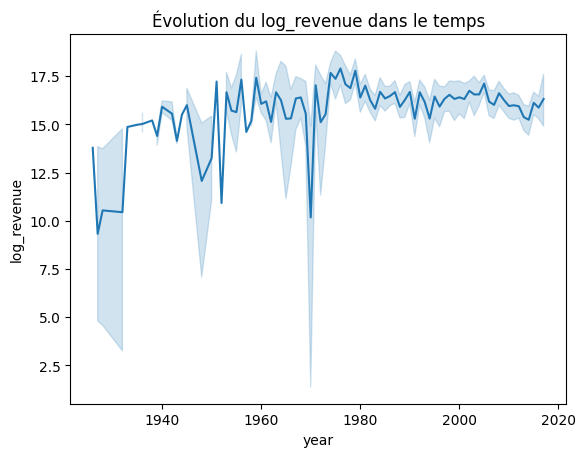

In [111]:
initial_data2 = initial_data[initial_data["year"] < 2024]
sns.lineplot(x="year", y="log_revenue", data=initial_data2)
plt.title("Évolution du log_revenue dans le temps")
plt.show()


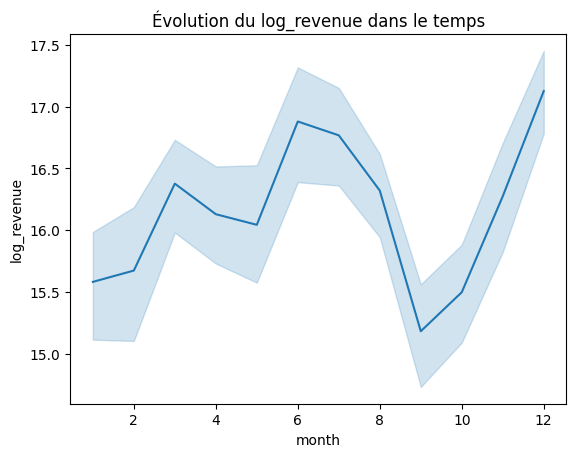

In [110]:
sns.lineplot(x="month", y="log_revenue", data=initial_data)
plt.title("Évolution du log_revenue dans le temps")
plt.show()


Fisrt model

In [123]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_squared_log_error


df_with_genres = initial_data.merge(df_final, on="Unnamed: 0")
data = df_with_genres.copy()

genre_cols = [c for c in df_final.columns if c.startswith("genre_")]
features = ["length","budget", "popularity_score", "month", "year"] + genre_cols

X = data[features]
y = data["revenue"]
# Séparer train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

